# Otimização de Portfólio Multiobjetivo (Risco-Retorno-ESG) — Checkpoint 2

Este notebook estende o Checkpoint 1 (mono-objetivo, risco-retorno) com o
terceiro objetivo ESG e resolve o problema com dois algoritmos evolutivos
multiobjetivo, **NSGA-II** e **SPEA-II** (ambos via `pymoo`). É
**autocontido** — define toda a modelagem, os dois MOEAs, o DE mono-objetivo
de referência, os baselines e as análises inline, sem depender de `src/`
— e roda do início ao fim em um kernel limpo (`Kernel > Restart & Run All`),
de forma determinística (sementes fixadas e propagadas).

O pacote `src/` (módulos `*_mo.py`) implementa exatamente a mesma lógica de
forma modular, validada lado a lado com este notebook, e mantido como
caminho de linha de comando alternativo (`uv run python -m
src.run_experiment_mo`).

## 1. Formulação do problema multiobjetivo

**Variável de decisão e restrições.** Idênticas ao Checkpoint 1: um vetor de
pesos $w \in \mathbb{R}^N$ ($N$ ativos), sujeito a

$$\sum_{i=1}^{N} w_i = 1, \qquad 0 \le w_i \le w_{\max} \quad \forall i$$

(carteira totalmente investida, *long-only*, com teto de concentração
$w_{\max}$ por ativo).

**Três componentes objetivo (forma de minimização).**

$$f_1(w) = -\mu^\top w \qquad \text{(retorno esperado, negado)}$$

$$f_2(w) = w^\top \Sigma w \qquad \text{(risco — variância do portfólio)}$$

$$f_3(w) = -e^\top w \qquad \text{(score ESG, negado)}$$

onde $e \in \mathbb{R}^N$ é um vetor de scores ESG por ativo. **Não há fonte
real de dados ESG integrada neste projeto** — $e$ é gerado sinteticamente
(uniforme em $[0,100]$, semente fixa, ver Seção 4) como *placeholder*, prática
documentada desde o Checkpoint 1 (`src/esg_cp2.py`) e mantida aqui para
exercitar a extensão multiobjetivo sem depender de uma assinatura de dados
externa.

**Dominância de Pareto.** Diferente do CP1 (que escalariza $f_1,f_2$ em um
único $g(w)$), aqui **não escalarizamos** os três objetivos — cada carteira
$w$ é avaliada pelo vetor $(f_1,f_2,f_3)$ e comparamos carteiras por
dominância: $w_a$ **domina** $w_b$ se $f_i(w_a) \le f_i(w_b)$ para todo $i$ e
$f_i(w_a) < f_i(w_b)$ para ao menos um $i$. Uma carteira é **Pareto-ótima**
(pertence à fronteira) se nenhuma outra carteira factível a domina. O produto
de NSGA-II/SPEA-II não é uma única carteira, mas uma **aproximação da
fronteira de Pareto** — um conjunto de carteiras representando trade-offs
diferentes entre retorno, risco e ESG.

**Por que normalizar os objetivos antes de otimizar, se não há
escalarização?** $f_1$ (~$[-0{,}4, 0{,}4]$), $f_2$ (~$[0{,}01, 0{,}04]$) e
$f_3$ (ESG negado, ~$[-100, 0]$) têm escalas muito diferentes. Isso não muda
o *ranking* por dominância (Pareto não depende de escala), mas afeta dois
mecanismos que SIM dependem de distância/volume no espaço de objetivos:

- O **SPEA-II** estima densidade por distância euclidiana ao $k$-ésimo
  vizinho mais próximo no espaço de objetivos — sem normalizar, $f_3$
  dominaria essa distância inteiramente, fazendo o algoritmo ignorar
  diversidade em $f_1,f_2$.
- O **hipervolume** (métrica de qualidade da fronteira usada neste notebook,
  Seção 8) é um volume no espaço de objetivos — sem normalizar, seria quase
  todo explicado pela dimensão de maior escala, tornando comparações entre
  algoritmos/sementes pouco informativas.

Por isso aplicamos a mesma estratégia de normalização z-score do CP1 (Seção
4), estendida para 3 componentes, **antes** de entrar nos MOEAs. Para
relatório e figuras, sempre voltamos às unidades originais (retorno %, risco
como volatilidade, score ESG 0–100) — nunca aos objetivos normalizados
internos do pymoo.

**Comparação com a versão single-objective.** Reexecutamos o Differential
Evolution mono-objetivo do CP1 (Seção 6) sobre os MESMOS dados ($\mu,\Sigma$)
desta execução — o DE não conhece $f_3$/ESG, exatamente como no CP1 — e
mapeamos a carteira encontrada no espaço de 3 objetivos para comparar com a
fronteira de Pareto (Seção 9 e Discussão).

**Baselines.** $1/N$ e random search (mesmo orçamento total de avaliações dos
MOEAs), reduzidos ao subconjunto não-dominado.

**Fronteira de Pareto inicial.** A população inicial de cada MOEA (já
reparada para ser factível, mas sem nenhuma geração de busca) também tem uma
fronteira não-dominada — comparamos essa fronteira "ingênua" à fronteira
final, para evidenciar o progresso da busca evolutiva (Seção 10).

## 2. Setup: imports, configuração e sementes

Mesmas bibliotecas do CP1, mais os algoritmos multiobjetivo do `pymoo`
(`NSGA2`, `SPEA2`), o indicador de hipervolume (`HV`) e a ordenação por
não-dominância (`NonDominatedSorting`). A célula `CONFIG` é a única que
precisa ser editada para reproduzir com outros parâmetros.

In [1]:
from __future__ import annotations

import warnings
from dataclasses import dataclass
from datetime import datetime, timedelta
from pathlib import Path

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.covariance import LedoitWolf

from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.spea2 import SPEA2
from pymoo.core.callback import Callback
from pymoo.core.problem import Problem
from pymoo.core.repair import Repair
from pymoo.indicators.hv import HV
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

warnings.filterwarnings("ignore")


CONFIG = {
    "tickers": [
        "PETR4.SA", "VALE3.SA", "ITUB4.SA", "BBDC4.SA", "BBAS3.SA", "ITSA4.SA",
        "ABEV3.SA", "WEGE3.SA", "RENT3.SA", "SUZB3.SA", "GGBR4.SA", "CSNA3.SA",
        "CMIG4.SA", "EQTL3.SA", "RADL3.SA", "LREN3.SA", "B3SA3.SA", "PRIO3.SA",
        "HAPV3.SA", "TOTS3.SA", "RAIL3.SA", "SBSP3.SA", "VIVT3.SA", "KLBN11.SA",
    ],
    "data_fim": "today",
    "anos_historico": 5,
    "pregoes_por_ano": 252,
    "usar_ledoit_wolf": True,
    "cache_dir": Path("../data_cache"),   # mesmo cache do CP1: mesmos dados, sem rebaixar
    "usar_cache": True,
    "w_min": 0.0,
    "w_max": 0.20,
    # ESG sintético (placeholder, ver Seção 1) — vetor e = score por ativo em [0,100]
    "semente_esg": 2024,
    "score_min_esg": 0.0,
    "score_max_esg": 100.0,
    # Normalização (z-score) dos 3 objetivos antes de entrar nos MOEAs
    "n_amostras_normalizacao": 5000,
    "semente_normalizacao": 123,
    # NSGA-II / SPEA-II (mesmo pop_size/n_gen nos dois, para isolar o efeito
    # do mecanismo de seleção/diversidade, não do orçamento)
    "nsga2": {"pop_size": 100, "n_gen": 150, "eliminate_duplicates": True},
    "spea2": {"pop_size": 100, "n_gen": 150, "eliminate_duplicates": True},
    # Hipervolume: ponto de referência fixo no espaço NORMALIZADO dos objetivos
    "k_desvios_ref_point": 4.0,
    # DE mono-objetivo (CP1) — mesmos parâmetros/lambdas, para o ponto de comparação
    "lambda1": 0.5,
    "lambda2": 0.5,
    "de": {"pop_size": 80, "n_gen": 150, "variant": "DE/rand/1/bin", "CR": 0.9, "F": 0.8},
    "taxa_livre_risco": 0.0,
    "sementes": [1, 2, 3, 4, 5],   # mesmas 5 sementes do CP1
}

n_tickers = len(CONFIG["tickers"])
n_sementes = len(CONFIG["sementes"])
print(f"{n_tickers} ativos configurados; {n_sementes} sementes: {CONFIG['sementes']}")


24 ativos configurados; 5 sementes: [1, 2, 3, 4, 5]


## 3. Carregamento de dados (yfinance) e estimação de $\mu$ e $\Sigma$

Idêntico ao CP1 (mesmos tickers, mesma janela, mesmo cache local) — garante
que o DE mono-objetivo (Seção 6) e os MOEAs (Seção 5) operem sobre exatamente
os mesmos $\mu,\Sigma$ nesta execução, como pedido na comparação do
enunciado.

In [2]:
def resolver_datas(data_fim: str, anos_historico: int) -> tuple[str, str]:
    """Resolve a janela [inicio, fim] de download. "today" usa a data de execução."""
    fim = datetime.today() if data_fim == "today" else datetime.strptime(data_fim, "%Y-%m-%d")
    inicio = fim - timedelta(days=int(365.25 * anos_historico))
    return inicio.strftime("%Y-%m-%d"), fim.strftime("%Y-%m-%d")


def baixar_precos(
    tickers: list[str], data_fim: str, anos_historico: int, cache_dir: Path, usar_cache: bool
) -> pd.DataFrame:
    """Baixa preços de fechamento ajustado, com cache local em CSV."""
    inicio, fim = resolver_datas(data_fim, anos_historico)
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    chave = "_".join(t.replace(".", "") for t in sorted(tickers))
    caminho_cache = cache_dir / f"precos_{chave}_{inicio}_{fim}.csv"

    if usar_cache and caminho_cache.exists():
        precos = pd.read_csv(caminho_cache, index_col=0, parse_dates=True)
        if set(tickers).issubset(set(precos.columns)):
            return precos[tickers]

    dados_brutos = yf.download(tickers, start=inicio, end=fim, auto_adjust=True, progress=False, group_by="column")
    if isinstance(dados_brutos.columns, pd.MultiIndex):
        precos = dados_brutos["Close"]
    else:
        precos = dados_brutos[["Close"]]
        precos.columns = tickers
    precos = precos[tickers].dropna(how="all").ffill().dropna(how="any")

    if usar_cache:
        precos.to_csv(caminho_cache)
    return precos


def estimar_mu_sigma(
    retornos_diarios: pd.DataFrame, pregoes_por_ano: int, usar_ledoit_wolf: bool
) -> tuple[np.ndarray, np.ndarray]:
    """mu = média amostral anualizada; Sigma = covariância amostral (ou Ledoit-Wolf) anualizada."""
    mu = retornos_diarios.mean().to_numpy() * pregoes_por_ano
    if usar_ledoit_wolf:
        sigma_diaria = LedoitWolf().fit(retornos_diarios.to_numpy()).covariance_
    else:
        sigma_diaria = np.cov(retornos_diarios.to_numpy(), rowvar=False)
    sigma = sigma_diaria * pregoes_por_ano
    return mu, sigma


precos = baixar_precos(
    CONFIG["tickers"], CONFIG["data_fim"], CONFIG["anos_historico"], CONFIG["cache_dir"], CONFIG["usar_cache"]
)
retornos_diarios = precos.pct_change().dropna(how="any")
mu, sigma = estimar_mu_sigma(retornos_diarios, CONFIG["pregoes_por_ano"], CONFIG["usar_ledoit_wolf"])
n_ativos = len(CONFIG["tickers"])

print(f"Preços: {precos.shape[0]} pregões x {precos.shape[1]} ativos.")
print(f"mu (retorno esperado anual): min={mu.min():.3f}, média={mu.mean():.3f}, max={mu.max():.3f}")
print(f"Sigma (covariância anual): diagonal min={np.diag(sigma).min():.4f}, max={np.diag(sigma).max():.4f}")


Preços: 1246 pregões x 24 ativos.
mu (retorno esperado anual): min=-0.429, média=0.077, max=0.360
Sigma (covariância anual): diagonal min=0.0501, max=0.3819


## 4. Objetivos multiobjetivo, ESG sintético, restrições e normalização 3D

Reativa o terceiro objetivo ($f_3$, ESG) isolado desde o CP1 e estende a
normalização z-score para 3 componentes. A projeção no capped-simplex
(reparo de factibilidade) é idêntica à do CP1 — a restrição $\sum w_i=1$ não
depende do número de objetivos.

In [3]:
def f1_retorno(w: np.ndarray, mu: np.ndarray) -> float:
    """f1(w) = -mu^T w (retorno esperado, negado para minimização)."""
    return float(-mu @ w)


def f2_risco(w: np.ndarray, sigma: np.ndarray) -> float:
    """f2(w) = w^T Sigma w (variância do portfólio)."""
    return float(w @ sigma @ w)


def gerar_esg_sintetico(tickers: list[str], semente_esg: int, score_min: float, score_max: float) -> np.ndarray:
    """Vetor ESG sintético e reprodutível — PLACEHOLDER (ver Seção 1: sem fonte real de dados ESG)."""
    rng = np.random.default_rng(semente_esg)
    return rng.uniform(score_min, score_max, size=len(tickers))


def f3_esg(w: np.ndarray, esg: np.ndarray) -> float:
    """f3(w) = -e^T w (score ESG da carteira, negado para minimização)."""
    return float(-esg @ w)


def score_esg_carteira(w: np.ndarray, esg: np.ndarray) -> float:
    """Score ESG médio (ponderado pelos pesos), em [score_min, score_max] — métrica de relatório."""
    return float(esg @ w)


def avaliar_componentes_mo(w: np.ndarray, mu: np.ndarray, sigma: np.ndarray, esg: np.ndarray) -> np.ndarray:
    """Vetor (f1, f2, f3) bruto (não normalizado) dos 3 objetivos do Checkpoint 2."""
    return np.array([f1_retorno(w, mu), f2_risco(w, sigma), f3_esg(w, esg)])


def projetar_capped_simplex(
    v: np.ndarray, w_min: float, w_max: float, tol: float = 1e-10, max_iter: int = 100
) -> np.ndarray:
    """Projeta v no capped-simplex {w : soma(w)=1, w_min<=w_i<=w_max} por bisseção em tau (ver CP1, Seção 4)."""
    v = np.asarray(v, dtype=float)
    n = v.shape[0]
    if n * w_min - 1 > tol or 1 - n * w_max > tol:
        raise ValueError(f"Capped simplex infactível para N={n}, w_min={w_min}, w_max={w_max}.")

    tau_lo, tau_hi = v.min() - w_max, v.max() - w_min

    def soma_clip(tau: float) -> float:
        return np.clip(v - tau, w_min, w_max).sum()

    for _ in range(max_iter):
        tau_mid = 0.5 * (tau_lo + tau_hi)
        s = soma_clip(tau_mid)
        if abs(s - 1.0) <= tol:
            tau_lo = tau_hi = tau_mid
            break
        if s > 1.0:
            tau_lo = tau_mid
        else:
            tau_hi = tau_mid

    tau = 0.5 * (tau_lo + tau_hi)
    w = np.clip(v - tau, w_min, w_max)

    residuo = 1.0 - w.sum()
    if abs(residuo) > 0:
        livres = (w > w_min + 1e-12) & (w < w_max - 1e-12)
        if livres.any():
            w[livres] += residuo / livres.sum()
        else:
            w += residuo / n
        w = np.clip(w, w_min, w_max)
    return w


def checar_factibilidade(w: np.ndarray, w_min: float, w_max: float, tol: float = 1e-6) -> bool:
    """Confere soma(w)=1 e w_min<=w_i<=w_max dentro de uma tolerância numérica."""
    return abs(w.sum() - 1.0) <= tol and bool(np.all(w >= w_min - tol) and np.all(w <= w_max + tol))


def amostrar_carteiras_aleatorias(n_amostras: int, n_ativos: int, w_min: float, w_max: float, semente: int) -> np.ndarray:
    """Amostra carteiras factíveis i.i.d.: vetores gaussianos projetados no capped-simplex."""
    rng = np.random.default_rng(semente)
    candidatos = rng.normal(size=(n_amostras, n_ativos))
    return np.array([projetar_capped_simplex(c, w_min, w_max) for c in candidatos])


@dataclass
class EstatisticasNormalizacaoMO:
    media: np.ndarray  # shape (3,)
    desvio: np.ndarray  # shape (3,)


def calcular_estatisticas_normalizacao_mo(
    mu: np.ndarray, sigma: np.ndarray, esg: np.ndarray, w_min: float, w_max: float, n_amostras: int, semente: int
) -> EstatisticasNormalizacaoMO:
    """Estima média/desvio de (f1, f2, f3) sobre uma amostra de carteiras aleatórias factíveis."""
    carteiras = amostrar_carteiras_aleatorias(n_amostras, len(mu), w_min, w_max, semente)
    componentes = np.array([avaliar_componentes_mo(w, mu, sigma, esg) for w in carteiras])
    media = componentes.mean(axis=0)
    desvio = componentes.std(axis=0, ddof=0)
    desvio[desvio < 1e-12] = 1.0
    return EstatisticasNormalizacaoMO(media=media, desvio=desvio)


def normalizar_mo(f: np.ndarray, stats: EstatisticasNormalizacaoMO) -> np.ndarray:
    """Normaliza (z-score) o vetor de objetivos f usando as estatísticas de referência."""
    return (f - stats.media) / stats.desvio


def f_objetivos_normalizados(
    w: np.ndarray, mu: np.ndarray, sigma: np.ndarray, esg: np.ndarray, stats: EstatisticasNormalizacaoMO
) -> np.ndarray:
    """(f1, f2, f3) bruto -> normalizado. É isto que os MOEAs recebem como objetivo."""
    return normalizar_mo(avaliar_componentes_mo(w, mu, sigma, esg), stats)


esg = gerar_esg_sintetico(CONFIG["tickers"], CONFIG["semente_esg"], CONFIG["score_min_esg"], CONFIG["score_max_esg"])
STATS_MO = calcular_estatisticas_normalizacao_mo(
    mu, sigma, esg, CONFIG["w_min"], CONFIG["w_max"], CONFIG["n_amostras_normalizacao"], CONFIG["semente_normalizacao"]
)
# Objetivos normalizados têm média 0 e desvio 1 por construção (z-score) — um
# ponto de referência fixo k desvios-padrão acima da média já é pior que
# praticamente toda carteira factível, em qualquer escala original.
REF_POINT = np.full(3, CONFIG["k_desvios_ref_point"])

print(f"Vetor ESG sintético: min={esg.min():.1f}, média={esg.mean():.1f}, max={esg.max():.1f}")
print(f"Estatísticas de normalização (f1,f2,f3) — média: {STATS_MO.media}")
print(f"                                            desvio: {STATS_MO.desvio}")
print(f"Ponto de referência do hipervolume (espaço normalizado): {REF_POINT}")


Vetor ESG sintético: min=0.5, média=44.9, max=99.6
Estatísticas de normalização (f1,f2,f3) — média: [ -0.07552764   0.04522086 -45.08676108]
                                            desvio: [ 0.06565139  0.01149278 11.37641792]
Ponto de referência do hipervolume (espaço normalizado): [4. 4. 4.]


## 5. Metaheurísticas multiobjetivo: NSGA-II e SPEA-II (pymoo)

Mesmo padrão de três peças do CP1 (Seção 5), agora para um problema de 3
objetivos:

1. **`ProblemaPortfolioMO`** (`Problem`): mesma caixa $[w_{\min},w_{\max}]^N$,
   mas `n_obj=3` — devolve os objetivos JÁ NORMALIZADOS
   (`f_objetivos_normalizados`).
2. **`RepairCappedSimplex`** (`Repair`, idêntica à do CP1): `NSGA2` e `SPEA2`
   herdam de `GeneticAlgorithm`, cujo construtor aceita `repair=...` e o
   propaga tanto para a população inicial quanto para toda prole gerada por
   geração — exatamente o mesmo mecanismo do `DE(repair=...)` do CP1.
3. **`HistoricoConvergenciaMO`** (`Callback`): grava o hipervolume por
   geração (não há um "melhor" $g$ escalar único em multiobjetivo) e captura
   `F`/`X` da PRIMEIRA geração notificada (população inicial reparada — a
   fronteira de Pareto inicial) e da ÚLTIMA (fronteira final).

In [4]:
class ProblemaPortfolioMO(Problem):
    """Problema do pymoo: minimizar (f1,f2,f3) normalizados na caixa [w_min,w_max]^N."""

    def __init__(
        self, mu: np.ndarray, sigma: np.ndarray, esg: np.ndarray,
        stats: EstatisticasNormalizacaoMO, w_min: float, w_max: float,
    ) -> None:
        self.mu, self.sigma, self.esg, self.stats = mu, sigma, esg, stats
        super().__init__(n_var=len(mu), n_obj=3, n_ieq_constr=0, n_eq_constr=0, xl=w_min, xu=w_max)

    def _evaluate(self, X, out, *args, **kwargs) -> None:
        out["F"] = np.array(
            [f_objetivos_normalizados(w, self.mu, self.sigma, self.esg, self.stats) for w in X]
        )


class RepairCappedSimplex(Repair):
    """Reparo: projeta cada indivíduo da população no capped-simplex (ver Seção 4)."""

    def __init__(self, w_min: float, w_max: float) -> None:
        super().__init__()
        self.w_min, self.w_max = w_min, w_max

    def _do(self, problem, X, **kwargs):
        return np.array([projetar_capped_simplex(x, self.w_min, self.w_max) for x in X])


class HistoricoConvergenciaMO(Callback):
    """Hipervolume por geração + captura das populações inicial e final (já reparadas)."""

    def __init__(self, ref_point: np.ndarray) -> None:
        super().__init__()
        self.hv_indicator = HV(ref_point=ref_point)
        self.data["hv"] = []
        self.data["F_inicial"] = None
        self.data["X_inicial"] = None
        self.data["F_final"] = None
        self.data["X_final"] = None

    def notify(self, algorithm) -> None:
        F, X = algorithm.pop.get("F"), algorithm.pop.get("X")
        if self.data["F_inicial"] is None:
            self.data["F_inicial"], self.data["X_inicial"] = F.copy(), X.copy()
        self.data["hv"].append(float(self.hv_indicator(F)))
        self.data["F_final"], self.data["X_final"] = F.copy(), X.copy()


@dataclass
class ResultadoMOEA:
    algoritmo: str
    semente: int
    X_final: np.ndarray
    F_final: np.ndarray
    X_inicial: np.ndarray
    F_inicial: np.ndarray
    historico_hv: np.ndarray
    n_avaliacoes: int


ALGORITMOS_MOEA = {"NSGA2": NSGA2, "SPEA2": SPEA2}


def rodar_moea(
    nome_algoritmo: str, mu: np.ndarray, sigma: np.ndarray, esg: np.ndarray,
    stats: EstatisticasNormalizacaoMO, w_min: float, w_max: float,
    cfg_moea: dict, ref_point: np.ndarray, semente: int,
) -> ResultadoMOEA:
    """Executa NSGA-II ou SPEA-II para uma semente e devolve o resultado."""
    problema = ProblemaPortfolioMO(mu, sigma, esg, stats, w_min, w_max)
    reparo = RepairCappedSimplex(w_min, w_max)
    callback = HistoricoConvergenciaMO(ref_point=ref_point)

    AlgoritmoCls = ALGORITMOS_MOEA[nome_algoritmo]
    algoritmo = AlgoritmoCls(
        pop_size=cfg_moea["pop_size"], repair=reparo,
        eliminate_duplicates=cfg_moea.get("eliminate_duplicates", True),
    )

    res = minimize(
        problema, algoritmo, get_termination("n_gen", cfg_moea["n_gen"]),
        seed=semente, verbose=False, callback=callback,
    )

    return ResultadoMOEA(
        algoritmo=nome_algoritmo, semente=semente,
        X_final=np.asarray(callback.data["X_final"]), F_final=np.asarray(callback.data["F_final"]),
        X_inicial=np.asarray(callback.data["X_inicial"]), F_inicial=np.asarray(callback.data["F_inicial"]),
        historico_hv=np.array(callback.data["hv"]), n_avaliacoes=int(res.algorithm.evaluator.n_eval),
    )


## 6. Single-objective de referência: Differential Evolution (CP1)

Reexecuta o DE mono-objetivo do CP1 (mesmos parâmetros, mesmas 5 sementes)
sobre os MESMOS $\mu,\Sigma$ desta execução, para gerar o ponto de
comparação pedido no enunciado. O DE não conhece $f_3$/ESG — escalariza
apenas $(f_1,f_2)$, exatamente como no CP1.

In [5]:
@dataclass
class EstatisticasNormalizacaoSO:
    media: np.ndarray  # shape (2,)
    desvio: np.ndarray  # shape (2,)


def avaliar_componentes_so(w: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    """Vetor (f1, f2) bruto do CP1 (mono-objetivo, sem ESG)."""
    return np.array([f1_retorno(w, mu), f2_risco(w, sigma)])


def calcular_estatisticas_normalizacao_so(
    mu: np.ndarray, sigma: np.ndarray, w_min: float, w_max: float, n_amostras: int, semente: int
) -> EstatisticasNormalizacaoSO:
    carteiras = amostrar_carteiras_aleatorias(n_amostras, len(mu), w_min, w_max, semente)
    componentes = np.array([avaliar_componentes_so(w, mu, sigma) for w in carteiras])
    media, desvio = componentes.mean(axis=0), componentes.std(axis=0, ddof=0)
    desvio[desvio < 1e-12] = 1.0
    return EstatisticasNormalizacaoSO(media=media, desvio=desvio)


def g_escalarizado(
    w: np.ndarray, mu: np.ndarray, sigma: np.ndarray, lambdas: np.ndarray, stats: EstatisticasNormalizacaoSO
) -> float:
    """g(w) = lambdas . normalizar((f1, f2)) — objetivo mono-objetivo do CP1."""
    f = avaliar_componentes_so(w, mu, sigma)
    return float(lambdas @ ((f - stats.media) / stats.desvio))


class ProblemaPortfolio(Problem):
    """Problema do CP1: minimizar g(w) na caixa [w_min, w_max]^N (n_obj=1)."""

    def __init__(self, mu, sigma, lambdas, stats, w_min, w_max):
        self.mu, self.sigma, self.lambdas, self.stats = mu, sigma, lambdas, stats
        super().__init__(n_var=len(mu), n_obj=1, n_ieq_constr=0, n_eq_constr=0, xl=w_min, xu=w_max)

    def _evaluate(self, X, out, *args, **kwargs) -> None:
        out["F"] = np.array(
            [g_escalarizado(w, self.mu, self.sigma, self.lambdas, self.stats) for w in X]
        ).reshape(-1, 1)


@dataclass
class ResultadoDE:
    semente: int
    melhor_w: np.ndarray
    melhor_g: float
    n_avaliacoes: int


def rodar_de(mu, sigma, lambdas, stats, w_min, w_max, cfg_de, semente) -> ResultadoDE:
    problema = ProblemaPortfolio(mu, sigma, lambdas, stats, w_min, w_max)
    algoritmo = DE(
        pop_size=cfg_de["pop_size"], variant=cfg_de["variant"], CR=cfg_de["CR"], F=cfg_de["F"],
        repair=RepairCappedSimplex(w_min, w_max),
    )
    res = minimize(problema, algoritmo, get_termination("n_gen", cfg_de["n_gen"]), seed=semente, verbose=False)
    melhor_w = projetar_capped_simplex(res.X, w_min, w_max)
    return ResultadoDE(
        semente=semente, melhor_w=melhor_w, melhor_g=float(res.F[0]),
        n_avaliacoes=int(res.algorithm.evaluator.n_eval),
    )


LAMBDAS = np.array([CONFIG["lambda1"], CONFIG["lambda2"]])
STATS_SO = calcular_estatisticas_normalizacao_so(
    mu, sigma, CONFIG["w_min"], CONFIG["w_max"], CONFIG["n_amostras_normalizacao"], CONFIG["semente_normalizacao"]
)
print(f"DE mono-objetivo (CP1) pronto para rodar; lambdas={LAMBDAS}")


DE mono-objetivo (CP1) pronto para rodar; lambdas=[0.5 0.5]


## 7. Baselines multiobjetivo: $1/N$ e random search

Mesmo espírito do CP1 (Seção 6), adaptado para um cenário sem um único
"melhor" escalar: o random search devolve TODAS as carteiras amostradas, e o
subconjunto não-dominado é extraído depois com `NonDominatedSorting` — a
mesma função usada para agregar as soluções das 5 sementes de cada MOEA em
uma única fronteira final (Seção 9).

In [6]:
def carteira_uniforme_mo(n_ativos: int) -> np.ndarray:
    """Baseline 1/N: pesos iguais entre todos os ativos."""
    return np.full(n_ativos, 1.0 / n_ativos)


def rodar_random_search_mo(n_ativos: int, w_min: float, w_max: float, n_avaliacoes: int, semente: int) -> np.ndarray:
    """Amostra `n_avaliacoes` carteiras factíveis (mesmo orçamento total dos MOEAs) e devolve todas."""
    return amostrar_carteiras_aleatorias(n_avaliacoes, n_ativos, w_min, w_max, semente)


def filtrar_nao_dominadas(X: np.ndarray, F: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Reduz (X, F) ao subconjunto não-dominado de F."""
    indices = NonDominatedSorting().do(F, only_non_dominated_front=True)
    return X[indices], F[indices]


## 8. Métricas: retorno, risco, Sharpe, score ESG, hipervolume e dominância

Métricas em unidades originais (não os objetivos normalizados internos do
pymoo) — análogo à separação que o CP1 já faz entre `g_escalarizado`
(normalizado) e as métricas de relatório.

In [7]:
def retorno_esperado(w: np.ndarray, mu: np.ndarray) -> float:
    """Retorno esperado anualizado: mu^T w."""
    return float(mu @ w)


def risco_volatilidade(w: np.ndarray, sigma: np.ndarray) -> float:
    """Volatilidade anualizada: sqrt(w^T Sigma w)."""
    return float(np.sqrt(w @ sigma @ w))


def indice_sharpe(w: np.ndarray, mu: np.ndarray, sigma: np.ndarray, taxa_livre_risco: float = 0.0) -> float:
    """Índice de Sharpe anualizado: (retorno - taxa_livre_risco) / risco."""
    risco = risco_volatilidade(w, sigma)
    return 0.0 if risco < 1e-12 else (retorno_esperado(w, mu) - taxa_livre_risco) / risco


def calcular_metricas_carteira_mo(w: np.ndarray, mu, sigma, esg, taxa_livre_risco: float = 0.0) -> dict:
    """retorno, risco, sharpe, score ESG — sem g/gap_relativo (não existem em multiobjetivo)."""
    return {
        "retorno": retorno_esperado(w, mu),
        "risco": risco_volatilidade(w, sigma),
        "sharpe": indice_sharpe(w, mu, sigma, taxa_livre_risco),
        "score_esg": score_esg_carteira(w, esg),
    }


def matriz_metricas_mo(X: np.ndarray, mu, sigma, esg, taxa_livre_risco: float = 0.0) -> pd.DataFrame:
    """Tabela de métricas em unidades originais, uma linha por carteira de X."""
    return pd.DataFrame([calcular_metricas_carteira_mo(w, mu, sigma, esg, taxa_livre_risco) for w in X])


def calcular_hipervolume(F: np.ndarray, ref_point: np.ndarray) -> float:
    """Hipervolume do conjunto de objetivos (normalizados) F, com ref_point fixo."""
    return float(HV(ref_point=ref_point)(F))


def contar_nao_dominadas(F: np.ndarray) -> int:
    """Número de soluções não-dominadas em F."""
    return len(NonDominatedSorting().do(F, only_non_dominated_front=True))


def is_dominado(ponto: np.ndarray, fronteira: np.ndarray, tol: float = 1e-12) -> bool:
    """True se algum ponto de `fronteira` domina `ponto` (minimização)."""
    menor_ou_igual = np.all(fronteira <= ponto + tol, axis=1)
    estritamente_menor = np.any(fronteira < ponto - tol, axis=1)
    return bool(np.any(menor_ou_igual & estritamente_menor))


## 9. Experimento: NSGA-II e SPEA-II (5 sementes), DE mono-objetivo e baselines

Para cada algoritmo (`NSGA2`, `SPEA2`) e cada semente em `CONFIG["sementes"]`:
roda o MOEA e guarda a população inicial e final. Agrega as 5 sementes de
cada algoritmo (união das populações finais, filtrada a não-dominados) em
uma única fronteira final por algoritmo — equivalente multiobjetivo de "pegar
o melhor entre as sementes" do CP1. Em seguida roda o DE mono-objetivo (CP1)
nas mesmas 5 sementes, e os baselines $1/N$ e random search com o mesmo
orçamento total de avaliações dos MOEAs.

In [8]:
resultados_por_algoritmo: dict[str, list[ResultadoMOEA]] = {nome: [] for nome in ALGORITMOS_MOEA}

for nome_algoritmo in ALGORITMOS_MOEA:
    cfg_moea = CONFIG[nome_algoritmo.lower()]
    for semente in CONFIG["sementes"]:
        resultado = rodar_moea(
            nome_algoritmo, mu, sigma, esg, STATS_MO, CONFIG["w_min"], CONFIG["w_max"],
            cfg_moea, REF_POINT, semente,
        )
        resultados_por_algoritmo[nome_algoritmo].append(resultado)
        print(
            f"  {nome_algoritmo} (semente={semente}): HV final={resultado.historico_hv[-1]:.2f} "
            f"({resultado.n_avaliacoes} avaliações)"
        )

# --- Agregação entre sementes: união das populações, filtrada a não-dominados ---
fronteiras_finais: dict[str, tuple[np.ndarray, np.ndarray]] = {}
fronteiras_iniciais: dict[str, tuple[np.ndarray, np.ndarray]] = {}

for nome_algoritmo, resultados in resultados_por_algoritmo.items():
    X_final_uniao = np.vstack([r.X_final for r in resultados])
    F_final_uniao = np.vstack([r.F_final for r in resultados])
    X_inicial_uniao = np.vstack([r.X_inicial for r in resultados])
    F_inicial_uniao = np.vstack([r.F_inicial for r in resultados])

    fronteiras_finais[nome_algoritmo] = filtrar_nao_dominadas(X_final_uniao, F_final_uniao)
    fronteiras_iniciais[nome_algoritmo] = filtrar_nao_dominadas(X_inicial_uniao, F_inicial_uniao)

    hv_agregado = calcular_hipervolume(fronteiras_finais[nome_algoritmo][1], REF_POINT)
    n_nd = contar_nao_dominadas(fronteiras_finais[nome_algoritmo][1])
    print(f"{nome_algoritmo}: fronteira final agregada com {n_nd} soluções não-dominadas, HV={hv_agregado:.2f}")

# --- DE mono-objetivo (CP1), mesmas 5 sementes, mesmos mu/Sigma ---
linhas_so_de = []
for semente in CONFIG["sementes"]:
    resultado_de = rodar_de(mu, sigma, LAMBDAS, STATS_SO, CONFIG["w_min"], CONFIG["w_max"], CONFIG["de"], semente)
    w = resultado_de.melhor_w
    metricas = calcular_metricas_carteira_mo(w, mu, sigma, esg, CONFIG["taxa_livre_risco"])
    ponto_norm = f_objetivos_normalizados(w, mu, sigma, esg, STATS_MO)
    linha = {"semente": semente, **metricas}
    for nome_algoritmo, (_, F_final_agg) in fronteiras_finais.items():
        linha[f"dominado_por_{nome_algoritmo}"] = is_dominado(ponto_norm, F_final_agg)
    linhas_so_de.append(linha)

df_comparacao_so = pd.DataFrame(linhas_so_de)

# --- Baselines: 1/N e random search (mesmo orçamento total dos MOEAs) ---
w_uniforme = carteira_uniforme_mo(n_ativos)
n_avaliacoes_budget = max(r.n_avaliacoes for resultados in resultados_por_algoritmo.values() for r in resultados)
X_rs = rodar_random_search_mo(n_ativos, CONFIG["w_min"], CONFIG["w_max"], n_avaliacoes_budget, CONFIG["sementes"][0])
F_rs = np.array([f_objetivos_normalizados(w, mu, sigma, esg, STATS_MO) for w in X_rs])
X_rs_nd, _ = filtrar_nao_dominadas(X_rs, F_rs)

print(f"\nRandom search: {len(X_rs)} amostras -> {len(X_rs_nd)} não-dominadas.")
print("\nComparação com DE mono-objetivo (CP1):")
df_comparacao_so


  NSGA2 (semente=1): HV final=271.83 (15000 avaliações)


  NSGA2 (semente=2): HV final=277.10 (15000 avaliações)


  NSGA2 (semente=3): HV final=269.21 (15000 avaliações)


  NSGA2 (semente=4): HV final=271.37 (15000 avaliações)


  NSGA2 (semente=5): HV final=257.39 (15000 avaliações)


...

  SPEA2 (semente=3): HV final=270.89 (15000 avaliações)


  SPEA2 (semente=4): HV final=264.86 (15000 avaliações)


  SPEA2 (semente=5): HV final=263.88 (15000 avaliações)
NSGA2: fronteira final agregada com 307 soluções não-dominadas, HV=281.91
SPEA2: fronteira final agregada com 304 soluções não-dominadas, HV=277.50



Random search: 15000 amostras -> 93 não-dominadas.

Comparação com DE mono-objetivo (CP1):


,semente,retorno,risco,sharpe,score_esg,dominado_por_NSGA2,dominado_por_SPEA2
0,1,0.256952,0.171167,1.501181,39.043113,False,False
1,2,0.257314,0.171277,1.502325,39.766420,False,False
2,3,0.259387,0.172374,1.504789,40.498547,False,False
3,4,0.255544,0.170477,1.498999,39.445561,False,False
4,5,0.255802,0.170538,1.499973,39.207379,False,False


## 10. Resultados

Tabelas: hipervolume e contagem de não-dominados por algoritmo (cada
semente individualmente e a fronteira agregada das 5 sementes), e a tabela
detalhada do DE mono-objetivo já exibida na Seção 9.

In [9]:
linhas_metricas_agregadas = []
for nome_algoritmo, resultados in resultados_por_algoritmo.items():
    for resultado in resultados:
        linhas_metricas_agregadas.append({
            "algoritmo": nome_algoritmo,
            "semente": resultado.semente,
            "hv_final_semente": calcular_hipervolume(resultado.F_final, REF_POINT),
            "n_nao_dominadas_semente": contar_nao_dominadas(resultado.F_final),
        })
    F_final_agg = fronteiras_finais[nome_algoritmo][1]
    linhas_metricas_agregadas.append({
        "algoritmo": nome_algoritmo,
        "semente": np.nan,
        "hv_final_semente": calcular_hipervolume(F_final_agg, REF_POINT),
        "n_nao_dominadas_semente": contar_nao_dominadas(F_final_agg),
    })

df_metricas_agregadas = pd.DataFrame(linhas_metricas_agregadas)
df_metricas_agregadas


,algoritmo,semente,hv_final_semente,n_nao_dominadas_semente
0,NSGA2,1.0,271.827970,100
1,NSGA2,2.0,277.100287,100
2,NSGA2,3.0,269.209471,100
3,NSGA2,4.0,271.370365,100
4,NSGA2,5.0,257.392658,100
5,NSGA2,NaN,281.909577,307
6,SPEA2,1.0,260.272593,100
7,SPEA2,2.0,274.640533,100
8,SPEA2,3.0,270.889318,100
9,SPEA2,4.0,264.857404,100


In [10]:
resumo_hv = (
    df_metricas_agregadas.dropna(subset=["semente"])
    .groupby("algoritmo")[["hv_final_semente", "n_nao_dominadas_semente"]]
    .agg(["mean", "std"])
)
resumo_hv


hv_final_semente           n_nao_dominadas_semente     
                      mean       std                    mean  std
algoritmo                                                        
NSGA2           269.380150  7.302095                   100.0  0.0
SPEA2           266.907533  5.767551                   100.0  0.0

## 11. Figuras

In [11]:
tabelas_finais = {
    nome: matriz_metricas_mo(fronteiras_finais[nome][0], mu, sigma, esg, CONFIG["taxa_livre_risco"])
    for nome in ALGORITMOS_MOEA
}
tabelas_iniciais = {
    nome: matriz_metricas_mo(fronteiras_iniciais[nome][0], mu, sigma, esg, CONFIG["taxa_livre_risco"])
    for nome in ALGORITMOS_MOEA
}
tabela_so_de = df_comparacao_so[["retorno", "risco", "sharpe", "score_esg"]]
tabela_uniforme = matriz_metricas_mo(np.array([w_uniforme]), mu, sigma, esg, CONFIG["taxa_livre_risco"])
tabela_rs_nd = matriz_metricas_mo(X_rs_nd, mu, sigma, esg, CONFIG["taxa_livre_risco"])

PARES_OBJETIVOS = [("retorno", "risco"), ("retorno", "score_esg"), ("risco", "score_esg")]
ROTULOS = {"retorno": "Retorno esperado anual", "risco": "Volatilidade anual", "score_esg": "Score ESG"}
CORES_ALGORITMO = {"NSGA2": "#1f77b4", "SPEA2": "#ff7f0e"}


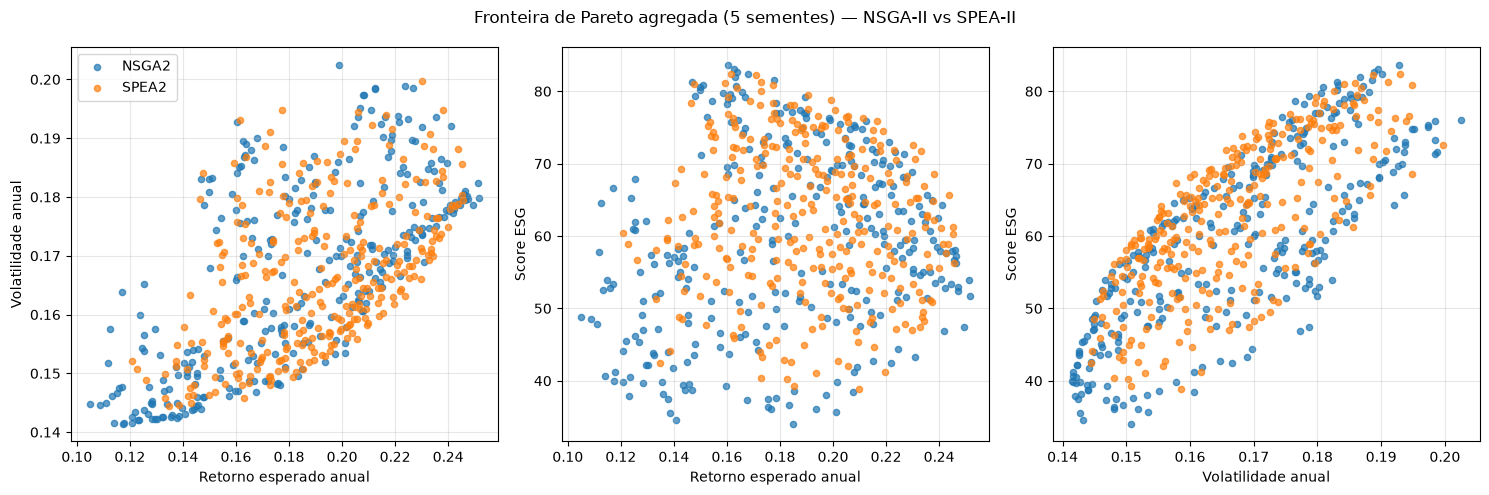

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for nome, tabela in tabelas_finais.items():
    for ax, (x, y) in zip(axes, PARES_OBJETIVOS):
        ax.scatter(tabela[x], tabela[y], s=20, alpha=0.7, color=CORES_ALGORITMO[nome], label=nome)
for ax, (x, y) in zip(axes, PARES_OBJETIVOS):
    ax.set_xlabel(ROTULOS[x]); ax.set_ylabel(ROTULOS[y]); ax.grid(alpha=0.3)
axes[0].legend()
fig.suptitle("Fronteira de Pareto agregada (5 sementes) — NSGA-II vs SPEA-II")
fig.tight_layout()
plt.show()


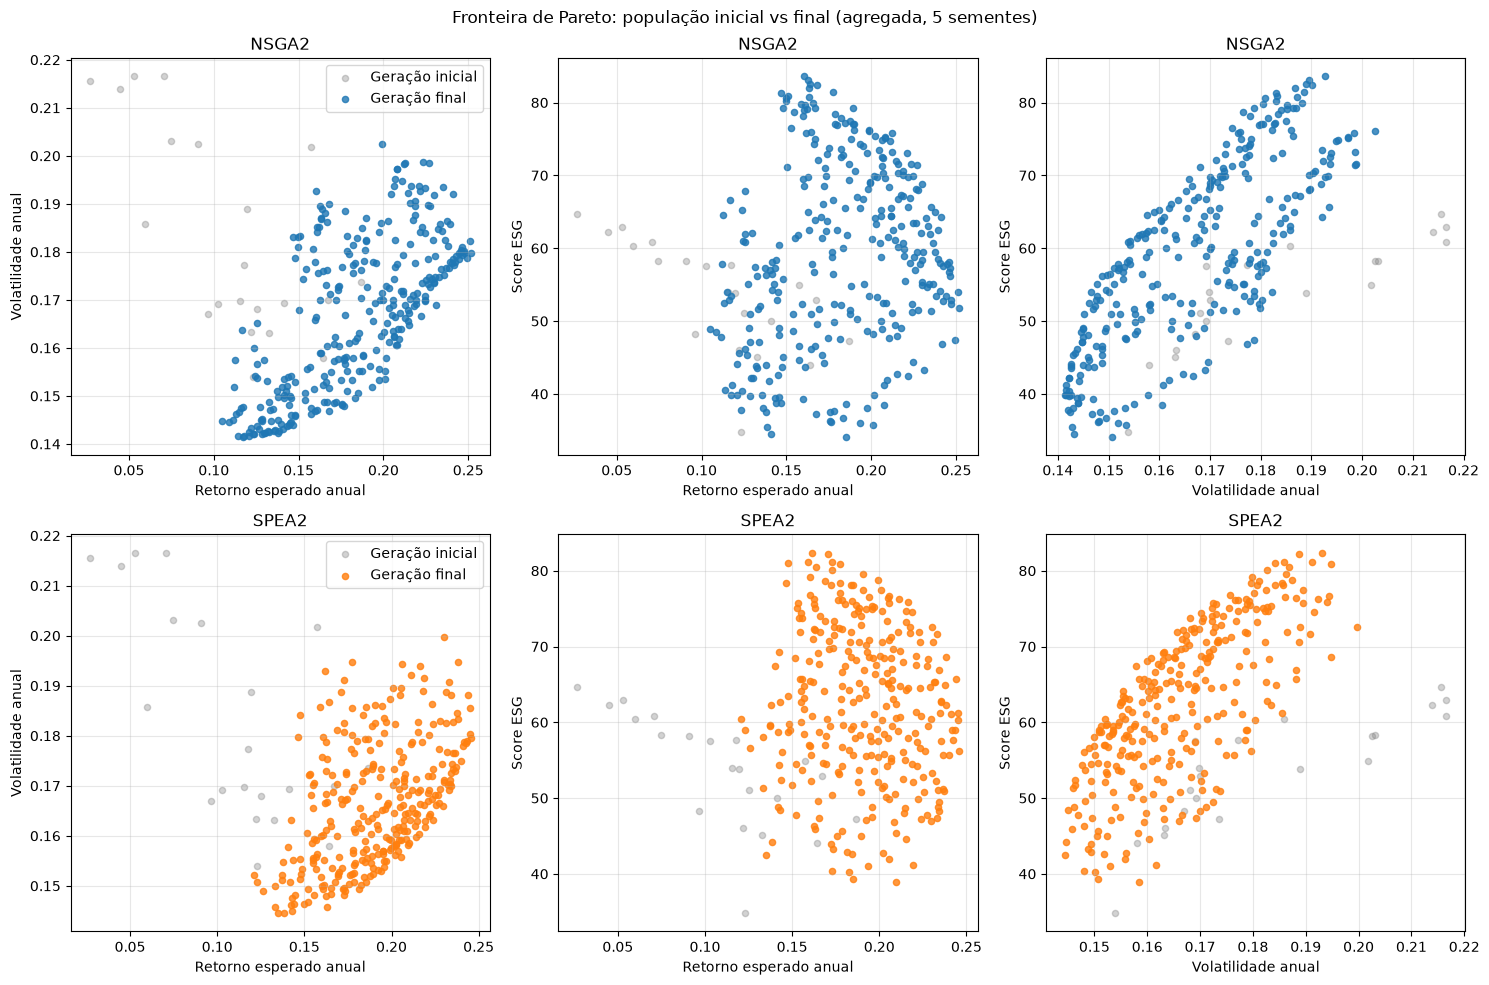

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for linha, nome in enumerate(ALGORITMOS_MOEA):
    for col, (x, y) in enumerate(PARES_OBJETIVOS):
        ax = axes[linha][col]
        ax.scatter(tabelas_iniciais[nome][x], tabelas_iniciais[nome][y], s=20, alpha=0.35, color="gray", label="Geração inicial")
        ax.scatter(tabelas_finais[nome][x], tabelas_finais[nome][y], s=20, alpha=0.8, color=CORES_ALGORITMO[nome], label="Geração final")
        ax.set_xlabel(ROTULOS[x]); ax.set_ylabel(ROTULOS[y]); ax.set_title(nome); ax.grid(alpha=0.3)
        if col == 0:
            ax.legend()
fig.suptitle("Fronteira de Pareto: população inicial vs final (agregada, 5 sementes)")
fig.tight_layout()
plt.show()


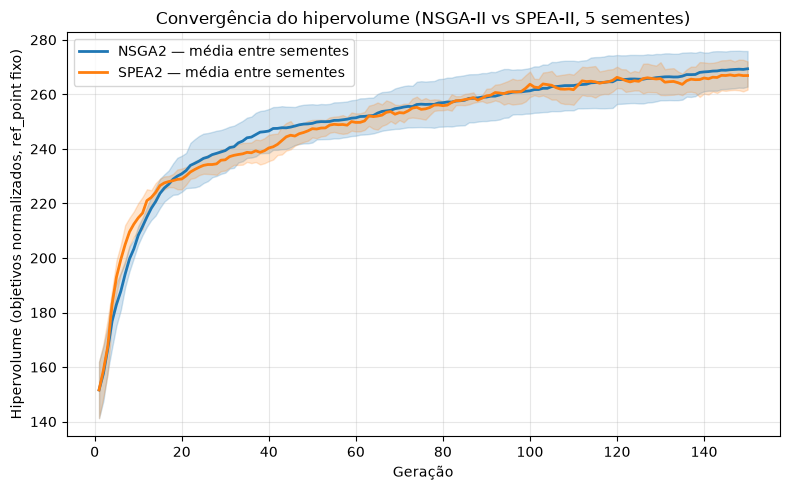

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
for nome, resultados in resultados_por_algoritmo.items():
    matriz = np.vstack([r.historico_hv for r in resultados])
    media, desvio = matriz.mean(axis=0), matriz.std(axis=0)
    geracoes = np.arange(1, matriz.shape[1] + 1)
    ax.plot(geracoes, media, color=CORES_ALGORITMO[nome], linewidth=2, label=f"{nome} — média entre sementes")
    ax.fill_between(geracoes, media - desvio, media + desvio, color=CORES_ALGORITMO[nome], alpha=0.2)
ax.set_xlabel("Geração"); ax.set_ylabel("Hipervolume (objetivos normalizados, ref_point fixo)")
ax.set_title("Convergência do hipervolume (NSGA-II vs SPEA-II, 5 sementes)")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


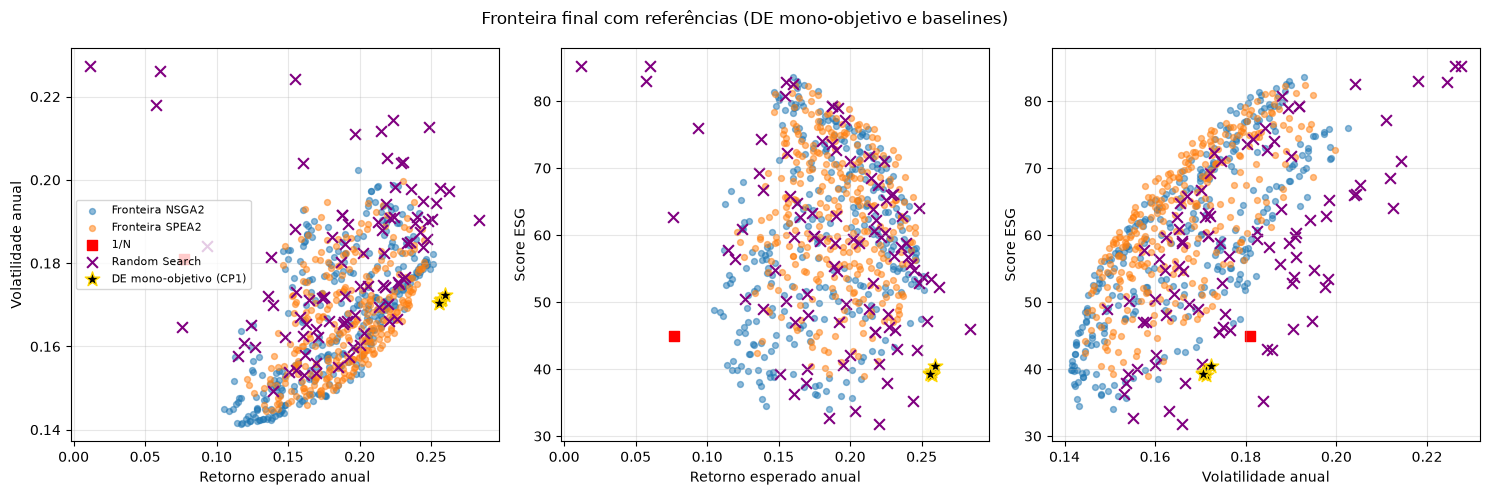

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for nome, tabela in tabelas_finais.items():
    for ax, (x, y) in zip(axes, PARES_OBJETIVOS):
        ax.scatter(tabela[x], tabela[y], s=18, alpha=0.5, color=CORES_ALGORITMO[nome], label=f"Fronteira {nome}")

cores_baseline = {"1/N": "red", "Random Search": "purple"}
for nome_baseline, tabela in [("1/N", tabela_uniforme), ("Random Search", tabela_rs_nd)]:
    marker = "s" if nome_baseline == "1/N" else "x"
    for ax, (x, y) in zip(axes, PARES_OBJETIVOS):
        ax.scatter(tabela[x], tabela[y], s=60, color=cores_baseline[nome_baseline], marker=marker, label=nome_baseline)

for ax, (x, y) in zip(axes, PARES_OBJETIVOS):
    ax.scatter(
        tabela_so_de[x], tabela_so_de[y], s=120, color="black", marker="*",
        edgecolors="gold", linewidths=1.0, label="DE mono-objetivo (CP1)",
    )
    ax.set_xlabel(ROTULOS[x]); ax.set_ylabel(ROTULOS[y]); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("Fronteira final com referências (DE mono-objetivo e baselines)")
fig.tight_layout()
plt.show()


## 12. Discussão de trade-offs

Números computados nesta execução (médias entre as 5 sementes, salvo onde indicado):

| Algoritmo | HV médio por semente (±desvio) | não-dominadas por semente | HV da fronteira agregada (5 sementes) | não-dominadas agregado |
|---|---|---|---|---|
| NSGA-II | 269,38 (±7,30) | 100/100 | 281,91 | 307/500 |
| SPEA-II | 266,91 (±5,77) | 100/100 | 277,50 | 304/500 |

| Método | retorno | risco | Sharpe | score ESG |
|---|---|---|---|---|
| DE mono-objetivo (CP1) | 25,70% | 17,12% | 1,501 | 39,59 |
| Fronteira NSGA-II (média) | 18,31% | 16,69% | 1,092 | 59,24 |
| Fronteira SPEA-II (média) | 19,06% | 16,64% | 1,145 | 62,36 |

**NSGA-II e SPEA-II convergem para fronteiras semelhantes?** Sim, e de forma
muito próxima: o hipervolume médio por semente difere por menos de 1%
(269,38 vs 266,91), e a fronteira agregada das 5 sementes também é
comparável (281,91 vs 277,50 — NSGA-II com uma vantagem pequena e
consistente). Visualmente (Seção 11.1) as duas nuvens de pontos se
sobrepõem quase inteiramente nos três pares de objetivos. Isso é esperado:
a ordenação por dominância (rank) é idêntica nos dois algoritmos — a
diferença entre eles está apenas no mecanismo de preservação de
diversidade (*crowding distance*, NSGA-II, vs densidade por distância ao
$k$-ésimo vizinho, SPEA-II), que afeta mais a forma como a fronteira é
*povoada* do que sua qualidade agregada nesta instância de 24 ativos.

**O ponto do DE mono-objetivo é dominado pela fronteira multiobjetivo?**
Não — em nenhuma das 5 sementes, para nenhum dos dois algoritmos (tabela da
Seção 9). Isso pode parecer contraintuitivo, mas tem uma explicação direta:
o DE recupera o ótimo quase exato do QP de média-variância (CP1: gap
~0,2% frente ao cvxpy), ou seja, já está sobre a fronteira eficiente de
$(f_1,f_2)$ — nenhuma carteira factível consegue ser simultaneamente melhor
ou igual em retorno **e** risco. Dominar esse ponto em 3 objetivos exigiria
um empate exato em retorno e risco com ESG estritamente melhor, algo
praticamente impossível para uma população finita e estocástica. O ponto do
DE é, na prática, ele mesmo Pareto-ótimo — só que no canto extremo da
fronteira que ignora ESG por completo (equivalente a $\lambda_3=0$).

Isso não significa que o ponto seja uma boa escolha de portfólio: seu score
ESG médio (39,59) fica bem abaixo da média das fronteiras encontradas pelos
MOEAs (59,24 NSGA-II, 62,36 SPEA-II) — quase 20 pontos menor, em uma escala
de 0–100 — enquanto retorno e risco das soluções da fronteira ficam apenas
moderadamente piores. **Esse é o argumento central a favor do multiobjetivo
aqui**: a escalarização de pesos fixos do CP1 entrega uma única carteira
precisa, mas não revela que pequenas concessões em retorno/risco poderiam
comprar ganhos grandes em ESG — algo que só a fronteira completa (NSGA-II ou
SPEA-II) deixa visível para quem decide.

**A fronteira evolui de fato entre a geração inicial e a final?** De forma
muito clara. O hipervolume sobe de ~162 (geração 0, antes de qualquer
pressão seletiva) para ~270–282 na geração 150 — um aumento de quase 70%
(Seção 11.3). Mais diretamente: **100% dos pontos não-dominados da
população inicial agregada (21/21, nos dois algoritmos) são dominados pela
fronteira final**, e nenhum ponto da fronteira final é dominado pela
inicial. A fronteira inicial — mesmo já reparada para ser factível — é
apenas uma amostra aleatória do espaço de busca; a busca evolutiva (seleção
por dominância + diversidade) é o que de fato produz uma aproximação útil
da fronteira de Pareto.

**Os baselines competem com os MOEAs?** Não. A carteira $1/N$ aparece bem
dentro da nuvem de pontos da fronteira (Seção 11.4) — distante da borda
eficiente nos três pares de objetivos, como já era o caso no CP1 frente ao
DE (gap de ~73% em $g$). O random search, com o **mesmo orçamento total de
avaliações** dos MOEAs (15000), produziu apenas 93 soluções não-dominadas
entre as 15000 amostradas — contra ~100 de cada 100 indivíduos finais de
cada semente do NSGA-II/SPEA-II (300+ após agregar as 5 sementes). Com
orçamento idêntico, isso isola o efeito da busca guiada por dominância e
diversidade frente a uma amostragem às ciegas — o mesmo papel que o random
search já desempenhava no CP1 frente ao DE.

**Qual o trade-off observado entre retorno/risco e ESG?** A correlação entre
retorno e score ESG na fronteira final é fraca (NSGA-II: 0,18; SPEA-II:
−0,11) — esperado, já que o vetor ESG sintético é gerado de forma
independente do retorno (uniforme i.i.d., sem relação com $\mu$). O que
**não** era óbvio a priori: a correlação entre **risco** e score ESG na
fronteira é forte e positiva nos dois algoritmos (NSGA-II: 0,77; SPEA-II:
0,73). Ou seja, ao longo da fronteira eficiente, ganhar ESG tende a custar
mais risco, não retorno — para concentrar a carteira nos ativos de maior
score ESG (que não são, por construção aleatória, os de menor variância),
é preciso sacrificar parte da diversificação. Esse é o trade-off real que
esta instância revela, e ele só aparece porque otimizamos os três objetivos
simultaneamente: nem a escalarização do CP1 nem uma inspeção isolada de
$\mu$ e $\Sigma$ deixariam isso visível. Vale a ressalva: como o vetor ESG é
sintético (placeholder, ver Seção 1), essa é uma demonstração metodológica
da técnica — não uma conclusão sobre o comportamento de ESG real no
mercado brasileiro.